In [1]:
from typing import Union
import matplotlib.pyplot as plt

def parse_listing(text: str):
    '''
    Parse XML array listings which has one entry per line.
    '''
    lines = text.split('\n')
    ret: list[float] = []
    for line in lines:
        line = line.strip()
        if line == '':
            continue
        assert line.startswith('<item>') and line.endswith('</item>')
        ret.append(float(line[6:-7].strip()))
    return ret
def parse_oplus_level_listing(text: str):
    '''
    Parse ColorOS brightness level listings which has one level per line.
    '''
    lines = text.split('\n')
    ret: list[list[float]] = []
    for line in lines:
        line = line.strip()
        if line == '':
            continue
        assert line.startswith('<level>') and line.endswith('</level>')
        ret.append([float(t) for t in line[7:-8].strip().split(',')])
    return ret
def make_listing(values: list[Union[int, float]]):
    '''
    Create XML array listing which has one entry per line.
    '''
    ret = ''
    for value in values:
        ret += f'<item>{value}</item>\n'
    return ret

In [2]:
def list_to_list_linear_map(val: float, src: list[float], dst: list[float]):
    '''
    Map the given value using the mapping defined by the two lists,
    interpolated using the linear approach.
    '''
    assert len(src) == len(dst)
    for i in range(len(src) - 1):
        assert src[i] <= src[i + 1]
    for i in range(len(src) - 1):
        if src[i] <= val <= src[i + 1]:
            break
    else:
        raise ValueError('Value out of range.')
    ratio = (val - src[i]) / (src[i + 1] - src[i])
    return dst[i] + (dst[i + 1] - dst[i]) * ratio

## Source data

Below is brightness metrics from ColorOS port (nits values seems mostly accurate, no auto brightness info),
LineageOS (seems not quite correct, and auto brightness is known to be problematic)
and crDroid (nits value not quite correct, auto brightness mostly works).

Terms:

- nits: The physical brightness value, used as a standard intermediary metric for communicating brightness.
- backlight: Legacy backlight value. Can describe non-HBM brightness levels only. Valid range from 1 to 255.
- register: The value stored in `/sys/class/backlight/panel0-backlight/brightness`.
  For our panel, the sustainable non-HBM range is from 1 to 2047 (0 is completely black),
  and the HBM (High Brightness Mode) range is from 2048 to 4095.

In [3]:
oos_brightness_profile = parse_oplus_level_listing(open('./cos_brightness_profile.txt', 'r').read())
los_backlight = parse_listing('''
    <item>0</item>
    <item>4</item>
    <item>8</item>
    <item>12</item>
    <item>16</item>
    <item>20</item>
    <item>24</item>
    <item>28</item>
    <item>32</item>
    <item>36</item>
    <item>40</item>
    <item>44</item>
    <item>48</item>
    <item>52</item>
    <item>56</item>
    <item>60</item>
    <item>64</item>
    <item>68</item>
    <item>72</item>
    <item>76</item>
    <item>80</item>
    <item>84</item>
    <item>88</item>
    <item>92</item>
    <item>96</item>
    <item>100</item>
    <item>104</item>
    <item>108</item>
    <item>112</item>
    <item>116</item>
    <item>120</item>
    <item>123</item>
    <item>127</item>
    <item>131</item>
    <item>135</item>
    <item>139</item>
    <item>143</item>
    <item>147</item>
    <item>151</item>
    <item>155</item>
    <item>159</item>
    <item>163</item>
    <item>167</item>
    <item>171</item>
    <item>175</item>
    <item>179</item>
    <item>183</item>
    <item>187</item>
    <item>191</item>
    <item>195</item>
    <item>199</item>
    <item>203</item>
    <item>207</item>
    <item>211</item>
    <item>215</item>
    <item>219</item>
    <item>223</item>
    <item>227</item>
    <item>231</item>
    <item>235</item>
    <item>239</item>
    <item>243</item>
    <item>246</item>
    <item>251</item>
    <item>255</item>
''')
los_nits = parse_listing('''
    <item>0.0</item>
    <item>2.1</item>
    <item>2.31</item>
    <item>2.63</item>
    <item>3.16</item>
    <item>3.73</item>
    <item>4.42</item>
    <item>5.45</item>
    <item>6.69</item>
    <item>8.07</item>
    <item>9.65</item>
    <item>11.32</item>
    <item>13.26</item>
    <item>15.59</item>
    <item>18.14</item>
    <item>20.68</item>
    <item>23.58</item>
    <item>26.38</item>
    <item>29.67</item>
    <item>32.83</item>
    <item>36.03</item>
    <item>39.31</item>
    <item>43.8</item>
    <item>47.95</item>
    <item>52.08</item>
    <item>56.86</item>
    <item>61.83</item>
    <item>67.93</item>
    <item>73.37</item>
    <item>79.96</item>
    <item>86.15</item>
    <item>90.75</item>
    <item>97.83</item>
    <item>105.67</item>
    <item>112.79</item>
    <item>120.33</item>
    <item>127.82</item>
    <item>135.71</item>
    <item>145.0</item>
    <item>153.32</item>
    <item>161.78</item>
    <item>170.61</item>
    <item>179.7</item>
    <item>190.25</item>
    <item>201.81</item>
    <item>212.07</item>
    <item>222.79</item>
    <item>234.01</item>
    <item>246.43</item>
    <item>257.49</item>
    <item>269.8</item>
    <item>281.41</item>
    <item>293.94</item>
    <item>307.58</item>
    <item>322.53</item>
    <item>335.82</item>
    <item>349.68</item>
    <item>364.86</item>
    <item>379.57</item>
    <item>398.55</item>
    <item>413.85</item>
    <item>429.97</item>
    <item>442.89</item>
    <item>461.76</item>
    <item>478.65</item>
''')
los_auto_lux = parse_listing('''
    <item>1</item>
    <item>4</item>
    <item>12</item>
    <item>20</item>
    <item>28</item>
    <item>47</item>
    <item>63</item>
    <item>86</item>
    <item>150</item>
    <item>160</item>
    <item>220</item>
    <item>270</item>
    <item>360</item>
    <item>420</item>
    <item>510</item>
    <item>620</item>
    <item>1000</item>
    <item>2000</item>
    <item>3100</item>
    <item>5000</item>
    <item>8000</item>
    <item>12000</item>
    <item>16000</item>
    <item>20000</item>
''')
los_auto_nits = parse_listing('''
    <item>2.0487</item>
    <item>4.8394</item>
    <item>15.2619</item>
    <item>30.2619</item>
    <item>46.671</item>
    <item>65.95</item>
    <item>80.46</item>
    <item>84.38</item>
    <item>89.51</item>
    <item>100.34</item>
    <item>102.21</item>
    <item>109.48</item>
    <item>114.19</item>
    <item>123.86</item>
    <item>129.18</item>
    <item>138.07</item>
    <item>145.62</item>
    <item>168.84</item>
    <item>234.9</item>
    <item>280</item>
    <item>320</item>
    <item>360</item>
    <item>405</item>
    <item>450</item>
    <item>500</item>
''')
crd_backlight = parse_listing('''
    <item>1</item>
    <item>255</item>
''')
crd_nits = parse_listing('''
    <item>1</item>
    <item>1100</item>
''')
crd_auto_lux = parse_listing('''
    <item>1</item>
    <item>4</item>
    <item>12</item>
    <item>20</item>
    <item>28</item>
    <item>47</item>
    <item>63</item>
    <item>86</item>
    <item>150</item>
    <item>220</item>
    <item>270</item>
    <item>360</item>
    <item>420</item>
    <item>510</item>
    <item>620</item>
    <item>1000</item>
    <item>2000</item>
    <item>3100</item>
    <item>3988</item>
    <item>5018</item>
    <item>6232</item>
    <item>7648</item>
    <item>9280</item>
    <item>11146</item>
    <item>13261</item>
    <item>15640</item>
    <item>18302</item>
    <item>21260</item>
    <item>24532</item>
    <item>28133</item>
    <item>32080</item>
    <item>36388</item>
    <item>41073</item>
    <item>46153</item>
    <item>51642</item>
    <item>63912</item>
    <item>78015</item>
    <item>94076</item>
    <item>112226</item>
    <item>132592</item>
    <item>155302</item>
    <item>180486</item>
    <item>208271</item>
    <item>223180</item>
    <item>255108</item>
''')
crd_auto_nits = parse_listing('''
    <item>2.0487</item>
    <item>4.8394</item>
    <item>15.2619</item>
    <item>33</item>
    <item>49</item>
    <item>62.95</item>
    <item>76.46</item>
    <item>84.38</item>
    <item>89.51</item>
    <item>100.34</item>
    <item>109.48</item>
    <item>115</item>
    <item>117.67</item>
    <item>122.72</item>
    <item>131.17</item>
    <item>141.19</item>
    <item>167.05</item>
    <item>234.9</item>
    <item>279</item>
    <item>300</item>
    <item>320</item>
    <item>340</item>
    <item>360</item>
    <item>380</item>
    <item>400</item>
    <item>420</item>
    <item>440</item>
    <item>460</item>
    <item>480</item>
    <item>500</item>
    <item>520</item>
    <item>540</item>
    <item>560</item>
    <item>580</item>
    <item>600</item>
    <item>620</item>
    <item>660</item>
    <item>700</item>
    <item>740</item>
    <item>780</item>
    <item>820</item>
    <item>860</item>
    <item>900</item>
    <item>940</item>
    <item>1000</item>
    <item>1100</item>
''')
oos_register_hbm_max = 4095
oos_register_sustainable_max = 2047
oos_register = [ item[1] for item in oos_brightness_profile ]
oos_nits = [ item[2] for item in oos_brightness_profile ]
los_auto_lux = [0, *los_auto_lux]
crd_auto_lux = [0, *crd_auto_lux]


## Explore ColorOS brightness profile

First let's plot and observe the ColorOS brightness profile, which seems mostly accurate.

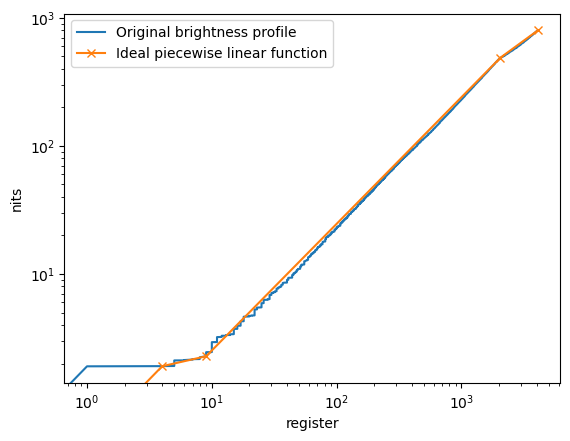

In [4]:
plt.plot(oos_register, oos_nits, label='Original brightness profile')
oos_register_key_points = [0, 4, 9, 2047, 4095]
plt.plot(
    oos_register_key_points,
    [ list_to_list_linear_map(item, oos_register, oos_nits) for item in oos_register_key_points ],
    marker='x',
    label='Ideal piecewise linear function'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('register')
plt.ylabel('nits')
plt.legend()

Conclusion: The register to nits mapping is mostly piecewise linear. The key points are:
- register=0: Completely black.
- register=4: The minimum brightness formerly set in LineageOS.
  As we have tested, register=3 appear darker
  but indeed unusable since the color accuracy is significantly bad (shifts to red).
- register=9: The minimum brightness set in stock ColorOS/OxygenOS 14 and crDroid (OnePlus 8T).
- register=2047: Sustainable maximum.
- register=4095: HBM maximum.

## Create a reasonable auto brightness mapping

First let's plot the former LineageOS and crDroid (OnePlus 8T) and compare them.
Since crDroid's brightness profile defines the sustainable maximum to be 1100nits (obviously incorrect),
we normalize to make the maximum nits of the auto brightness curve match the one of LineageOS.

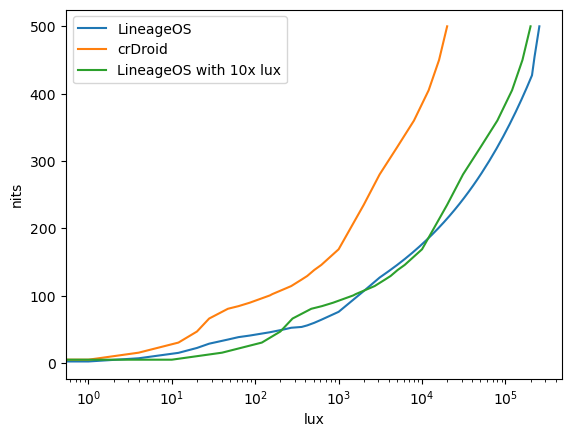

In [5]:
crd_auto_nits_max = max(*crd_auto_nits)
los_auto_nits_max = max(*los_auto_nits)
plt.plot(crd_auto_lux, [item / crd_auto_nits_max * los_auto_nits_max for item in crd_auto_nits], label='LineageOS')
plt.plot([item for item in los_auto_lux], los_auto_nits, label='crDroid')
plt.plot([item * 10 for item in los_auto_lux], los_auto_nits, label='LineageOS with 10x lux')
plt.xscale('log')
plt.xlabel('lux')
plt.ylabel('nits')
plt.legend()

This aligns with our observation that LineageOS' auto brightness is constantly significantly too bright
while crDroid's auto brightness mostly works.

However, by comparing the lux readings from LineageOS and crDroid (OnePlus 8T) differs wildly (the former is way higher).
The cause is the difference of kernel sensor config.
So we first change lemonades' kernel sensor config
(`/kernel/oneplus/sm8250/arch/arm64/boot/dts/vendor/oplus/lemonades/kona-sensor.dtsi`)
to match [the one in crDroid (OnePlus 8T)](https://github.com/crdroidandroid/android_kernel_oneplus_sm8250/blob/16.0/arch/arm64/boot/dts/vendor/oplus/lemonades/kona-sensor.dtsi#L45).

After this, we use crDroid's auto brightness curve extrapolate it far enough.
Still, crDroid's 1100nits sustainable maximum is obviously wrong. We normalize its 1100nits to the correct sustainable maximum.
Then we make a simple ideal mathematical function that is close enough to the curve as our auto brightness curve.

Finally, it can be found by experiment that the extra reading (after changing the kernel config)
contributed by "reflection" when the screen is displaying white under max sustainable brightness 
and moderate ambient light is approximately 225 lux.
We must prevent our suto brightness lux-nits curve from intersecting with the self-reflex lux-nits line,
since this can completely prevent the screen brightness from going down to zero even in an ideal dark room.
Ideally the self-reflex lux-nits line should be far above our curve to make auto brightness adequately consistent
between bright and dark mode UI.
Hence we do the `p_sum` between two curves.

Ideal curve max nits: 789.0413347827778


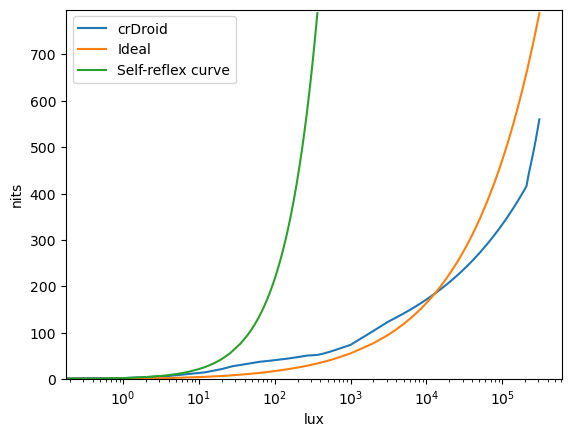

In [6]:
from math import exp, isclose, log

auto_lux = [*crd_auto_lux]
max_sustainable_nits = list_to_list_linear_map(oos_register_sustainable_max, oos_register, oos_nits)
max_hbm_nits = list_to_list_linear_map(oos_register_hbm_max, oos_register, oos_nits)
auto_nits = [item / 1100 * max_sustainable_nits for item in crd_auto_nits]

# Extrapolate far enough into HBM
# auto_lux = auto_lux[:-1]
# auto_nits = auto_nits[:-1]
point = (auto_lux[-1], auto_nits[-1])
slope = (
    auto_nits[-1] - auto_nits[-2]
) / (
    auto_lux[-1] - auto_lux[-2]
)

for extended_nit in [ 520, 560 ]:
    auto_nits.append(extended_nit)
    auto_lux.append(
        point[0] + (auto_nits[-1] - point[1]) / slope
    )

max_sustainable_reflex_lux = 225

def p_sum(a, b, p):
    if isclose(a, 0) or isclose(b, 0):
        return min(a, b)
    return ((a ** p + b ** p)) ** (1/p)

plt.plot(auto_lux, auto_nits, label='crDroid')
ideal_pivot = (
    list_to_list_linear_map(180, auto_nits, auto_lux),
    180
)
ideal_auto_lux = auto_lux[:]
ideal_auto_nits = [
    p_sum(
        (item / ideal_pivot[0]) ** (1/2.2) * ideal_pivot[1]
        , item / 2 / max_sustainable_reflex_lux * max_sustainable_nits,
        -1
    )
for item in ideal_auto_lux]
plt.plot(ideal_auto_lux, ideal_auto_nits, label='Ideal')
print('Ideal curve max nits:', max(*ideal_auto_nits))
auto_lux = ideal_auto_lux
auto_nits = ideal_auto_nits
plt.xscale('log')
plt.xlabel('lux')
plt.ylabel('nits')
plt.ylim(0, max_hbm_nits)

auto_reflex_white_lux = [item / max_sustainable_nits * max_sustainable_reflex_lux for item in auto_nits]
auto_reflex_black_lux = [0.0 for item in auto_nits]
plt.plot(auto_reflex_white_lux, auto_nits, label='Self-reflex curve')
plt.legend()

(27.842265069440426, 8.310679508832946)
(24.0, 7.561782054667992)


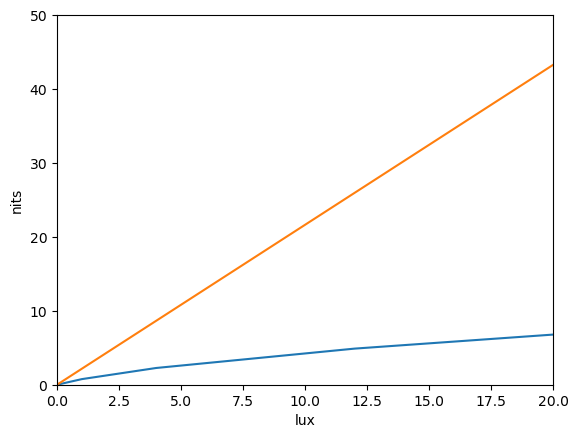

In [7]:
def simulate_brightness_change(
    env_lux: float,
    start_nits: float,
    auto_lux: list[float],
    auto_nits: list[float],
    auto_reflex_lux: list[float],
    /,
    step_lim: tuple[float, float] = (0.95, 1.05),
    lux_change_thresh: tuple[float, float] = (1, 1)
):
    eps = 1e-2
    curr_nits = start_nits
    min_nits, max_nits = min(*auto_nits), max(*auto_nits)
    min_lux, max_lux = min(*auto_lux), max(*auto_lux)
    while True:
        prev_nits = curr_nits
        reflex_lux = list_to_list_linear_map(
            curr_nits,
            auto_nits, auto_reflex_lux
        )
        should_lux = list_to_list_linear_map(
            curr_nits,
            auto_nits, auto_lux
        )
        curr_lux = reflex_lux + env_lux
        if lux_change_thresh[0] * should_lux <= curr_lux <= lux_change_thresh[1] * should_lux:
            break
        curr_nits = list_to_list_linear_map(
            max(min_lux, min(max_lux, curr_lux)),
            auto_lux, auto_nits,
        )
        curr_nits = max(step_lim[0] * prev_nits, min(step_lim[1] * prev_nits, curr_nits))
        curr_nits = max(min_nits, min(max_nits, curr_nits))
        if abs(curr_nits - prev_nits) < eps:
            break
    return curr_lux, curr_nits

plt.plot(auto_lux, auto_nits)
plt.plot(auto_reflex_white_lux, auto_nits)
plt.xlim(0, 20)
plt.ylim(0, 50)
plt.xlabel('lux')
plt.ylabel('nits')
print(simulate_brightness_change(24, 150, auto_lux, auto_nits, auto_reflex_white_lux))
print(simulate_brightness_change(24, 150, auto_lux, auto_nits, auto_reflex_black_lux))

## Final Answers

Brightness map for `configs/display/displayconfig.xml`:

In [8]:
text = ''
text += '    <screenBrightnessMap interpolation="linear">\n'
for level in oos_register_key_points:
    text += '        <point>\n'
    text += f'            <value>{level / oos_register_hbm_max}</value>\n'
    text += f'            <nits>{list_to_list_linear_map(level, oos_register, oos_nits)}</nits>\n'
    text += '        </point>\n'
text += '    </screenBrightnessMap>\n'
print(text)

    <screenBrightnessMap interpolation="linear">
        <point>
            <value>0.0</value>
            <nits>0.0</nits>
        </point>
        <point>
            <value>0.0009768009768009768</value>
            <nits>1.9087942</nits>
        </point>
        <point>
            <value>0.002197802197802198</value>
            <nits>2.2829435</nits>
        </point>
        <point>
            <value>0.4998778998778999</value>
            <nits>486.74194</nits>
        </point>
        <point>
            <value>1.0</value>
            <nits>796.74475</nits>
        </point>
    </screenBrightnessMap>



Global HBM parameters for `configs/display/displayconfig.xml`:

In [9]:
print('Transition point:', oos_register_sustainable_max / oos_register_hbm_max)
print('Minimum lux:', list_to_list_linear_map(max_sustainable_nits, auto_nits, auto_lux))

Transition point: 0.4998778998778999
Minimum lux: 107013.0143748875


Auto brightness lux values for `overlay/OPlusFrameworksResTarget/res/values/config.xml`:

In [10]:
print(make_listing([ int(item) for item in auto_lux[1:] ]).strip())

<item>1</item>
<item>4</item>
<item>12</item>
<item>20</item>
<item>28</item>
<item>47</item>
<item>63</item>
<item>86</item>
<item>150</item>
<item>220</item>
<item>270</item>
<item>360</item>
<item>420</item>
<item>510</item>
<item>620</item>
<item>1000</item>
<item>2000</item>
<item>3100</item>
<item>3988</item>
<item>5018</item>
<item>6232</item>
<item>7648</item>
<item>9280</item>
<item>11146</item>
<item>13261</item>
<item>15640</item>
<item>18302</item>
<item>21260</item>
<item>24532</item>
<item>28133</item>
<item>32080</item>
<item>36388</item>
<item>41073</item>
<item>46153</item>
<item>51642</item>
<item>63912</item>
<item>78015</item>
<item>94076</item>
<item>112226</item>
<item>132592</item>
<item>155302</item>
<item>180486</item>
<item>208271</item>
<item>223180</item>
<item>255108</item>
<item>279105</item>
<item>307967</item>


Auto brightness nits values for `overlay/OPlusFrameworksResTarget/res/values/config.xml`:

In [11]:
print(make_listing([ float(item) for item in auto_nits ]).strip())

<item>0.0</item>
<item>0.757829396275919</item>
<item>2.2650184644735645</item>
<item>4.884755017350441</item>
<item>6.78214042075644</item>
<item>8.341423688579544</item>
<item>11.323205727108803</item>
<item>13.376241609490584</item>
<item>15.89598340790672</item>
<item>21.42758694705237</item>
<item>26.15342478597664</item>
<item>29.04228146270301</item>
<item>33.584494733762696</item>
<item>36.274416512787255</item>
<item>39.941729171208706</item>
<item>43.971515762899436</item>
<item>55.47846532226957</item>
<item>77.27273516610973</item>
<item>95.02802263828113</item>
<item>106.94460592428531</item>
<item>119.06425497505188</item>
<item>131.7091286246349</item>
<item>144.85445676162</item>
<item>158.44400786590626</item>
<item>172.4634044597517</item>
<item>186.87783798702856</item>
<item>201.65919311479124</item>
<item>216.80618951636356</item>
<item>232.28433715604106</item>
<item>248.08957189890458</item>
<item>264.2035630658876</item>
<item>280.61879149560684</item>
<item>297

Brightness settings values for `overlay/OPlusFrameworksResTarget/res/values/config.xml`:

In [12]:
print('Min:', 4 / oos_register_hbm_max)
print('Dim:', 9 / oos_register_hbm_max)
print('Doze:', 9 / oos_register_hbm_max)
print('Default:', 511 / oos_register_hbm_max)
print('Max:', 1.0)

Min: 0.0009768009768009768
Dim: 0.002197802197802198
Doze: 0.002197802197802198
Default: 0.12478632478632479
Max: 1.0
